# 05 Mock Cart Features

## Scope

Build the final cart-level input table for Notebook 06.

Pipeline data outputs:

```text
data/processed/mock_cart_features.csv
data/processed/mock_cart_items.csv
```

Notebook-specific audit, diagnostics, config, and plots:

```text
outputs/05_mock_cart_features/
```


In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 240)

RANDOM_SEED = 42
N_CARTS = 50
MIN_ITEMS_PER_CART = 1
MAX_ITEMS_PER_CART = 4

SIMULATION_CONFIG = {
    "random_seed": RANDOM_SEED,
    "n_carts": N_CARTS,
    "min_items_per_cart": MIN_ITEMS_PER_CART,
    "max_items_per_cart": MAX_ITEMS_PER_CART,
    "two_size_cart_probability": 0.28,
    "duplicate_variant_probability": 0.18,
    "size_options": "XS,S,M,L,XL",
}

rng = np.random.default_rng(RANDOM_SEED)
random.seed(RANDOM_SEED)


def find_repo_root(start=None):
    current = Path(start or Path.cwd()).resolve()
    for path in [current, *current.parents]:
        if (path / "notebooks").exists() and (path / "data").exists():
            return path
    if current.name == "notebooks":
        return current.parent
    return current


REPO_ROOT = find_repo_root()
PROCESSED_DIR = REPO_ROOT / "data" / "processed"
OUTPUTS_DIR = REPO_ROOT / "outputs"
NOTEBOOK_OUTPUT_DIR = OUTPUTS_DIR / "05_mock_cart_features"
PLOTS_DIR = NOTEBOOK_OUTPUT_DIR / "plots"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

PATHS = {
    "online_model_base": PROCESSED_DIR / "online_retail_model_base.csv",
    "online_scores": PROCESSED_DIR / "online_retail_test_scores.csv",
    "fit_signals": PROCESSED_DIR / "fit_signals.csv",
    "review_signals": PROCESSED_DIR / "review_signals.csv",
    "review_handoff": PROCESSED_DIR / "review_signal_handoff.csv",
}

OUTPUT_PATHS = {
    "mock_cart_features": PROCESSED_DIR / "mock_cart_features.csv",
    "mock_cart_items": PROCESSED_DIR / "mock_cart_items.csv",
    "mock_product_signal_map": NOTEBOOK_OUTPUT_DIR / "mock_product_signal_map.csv",
    "feature_diagnostics": NOTEBOOK_OUTPUT_DIR / "mock_cart_feature_diagnostics.csv",
    "simulation_config": NOTEBOOK_OUTPUT_DIR / "mock_cart_simulation_config.csv",
}

print("Repo root:", REPO_ROOT)
print("Processed data dir:", PROCESSED_DIR)
print("Notebook output dir:", NOTEBOOK_OUTPUT_DIR)
print("Plots dir:", PLOTS_DIR)
for name, path in PATHS.items():
    print(f"{name}: {path}")


Repo root: C:\Users\monster\Desktop\returnshield-ai
Processed data dir: C:\Users\monster\Desktop\returnshield-ai\data\processed
Notebook output dir: C:\Users\monster\Desktop\returnshield-ai\outputs\05_mock_cart_features
Plots dir: C:\Users\monster\Desktop\returnshield-ai\outputs\05_mock_cart_features\plots
online_model_base: C:\Users\monster\Desktop\returnshield-ai\data\processed\online_retail_model_base.csv
online_scores: C:\Users\monster\Desktop\returnshield-ai\data\processed\online_retail_test_scores.csv
fit_signals: C:\Users\monster\Desktop\returnshield-ai\data\processed\fit_signals.csv
review_signals: C:\Users\monster\Desktop\returnshield-ai\data\processed\review_signals.csv
review_handoff: C:\Users\monster\Desktop\returnshield-ai\data\processed\review_signal_handoff.csv


## 1. Load inputs

Run 01, 02, 03, and 04 before this notebook.

Generated CSV files stay local under `data/processed/` and `outputs/`.


In [2]:
def read_required_csv(path: Path, label: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Missing {label}: {path}")
    df = pd.read_csv(path)
    print(f"Loaded {label}: {df.shape}")
    return df


online_base = read_required_csv(PATHS["online_model_base"], "online model base")
online_scores = read_required_csv(PATHS["online_scores"], "online test scores")
fit_signals = read_required_csv(PATHS["fit_signals"], "fit signals")
review_signals = read_required_csv(PATHS["review_signals"], "review signals")
review_handoff = read_required_csv(PATHS["review_handoff"], "review signal handoff")

print("\nOnline score columns:", list(online_scores.columns))
print("\nFit signal columns:", list(fit_signals.columns)[:30])
print("\nReview signal columns:", list(review_signals.columns)[:30])
print("\nReview handoff columns:", list(review_handoff.columns))


Loaded online model base: (536704, 12)
Loaded online test scores: (109518, 16)
Loaded fit signals: (7228, 31)
Loaded review signals: (7174, 27)
Loaded review signal handoff: (5, 16)

Online score columns: ['InvoiceDate', 'StockCode', 'CustomerID', 'Country', 'log_unit_price', 'invoice_hour', 'invoice_dayofweek', 'invoice_month', 'evening_purchase', 'customer_history_available', 'is_return', 'selected_model', 'selected_model_score', 'selected_model_calibrated_score', 'rf_history_smoothed_score', 'logistic_history_score']

Fit signal columns: ['source', 'item_id', 'category', 'item_review_count', 'unique_user_count', 'fit_signal_count', 'fit_issue_count', 'too_small_count', 'too_large_count', 'raw_fit_issue_rate', 'item_fit_issue_score', 'fit_signal_reliability_weight', 'length_signal_count', 'raw_length_issue_rate', 'item_length_issue_score', 'length_signal_reliability_weight', 'review_text_count', 'raw_review_size_signal_rate', 'review_size_signal_rate', 'raw_review_quality_signal_rate

## 2. Helpers

Flexible column lookup keeps the integration notebook tolerant to small naming changes in earlier outputs.


In [3]:
def first_existing_column(df: pd.DataFrame, candidates, required=False, label="column"):
    for col in candidates:
        if col in df.columns:
            return col
    if required:
        raise KeyError(f"Missing required {label}. Tried: {candidates}")
    return None


def percentile_rank_score(series: pd.Series) -> pd.Series:
    numeric = pd.to_numeric(series, errors="coerce")
    if numeric.notna().sum() == 0:
        return pd.Series(np.nan, index=series.index)
    return numeric.rank(pct=True, method="average")


def weighted_average_available(values, weights):
    values = pd.Series(values, dtype="float")
    weights = pd.Series(weights, dtype="float")
    available = values.notna() & weights.notna() & (weights > 0)

    if not available.any():
        return np.nan

    return float((values[available] * weights[available]).sum() / weights[available].sum())


def feature_diagnostic_row(df, column, layer, meaning):
    if column not in df.columns:
        return {
            "column": column,
            "layer": layer,
            "meaning": meaning,
            "non_missing_share": 0.0,
            "mean": np.nan,
            "std": np.nan,
            "p50": np.nan,
            "p95": np.nan,
            "p95_minus_p50": np.nan,
        }

    raw = df[column]
    non_missing_share = raw.notna().mean()

    numeric = pd.to_numeric(raw, errors="coerce")
    clean = numeric.dropna()

    if clean.empty:
        return {
            "column": column,
            "layer": layer,
            "meaning": meaning,
            "non_missing_share": non_missing_share,
            "mean": np.nan,
            "std": np.nan,
            "p50": np.nan,
            "p95": np.nan,
            "p95_minus_p50": np.nan,
        }

    p50 = clean.quantile(0.50)
    p95 = clean.quantile(0.95)

    return {
        "column": column,
        "layer": layer,
        "meaning": meaning,
        "non_missing_share": non_missing_share,
        "mean": clean.mean(),
        "std": clean.std(),
        "p50": p50,
        "p95": p95,
        "p95_minus_p50": p95 - p50,
    }


## 3. Transaction layer

The Online Retail model score is converted into a percentile-rank signal.

`selected_model_score` is preferred when available because it is the raw selected model output from Notebook 02. The rank signal is used for ordering, not as a calibrated probability.

The final schema keeps the transaction model signal and the available transaction context field.


In [4]:
risk_col = first_existing_column(
    online_scores,
    [
        "selected_model_score",
        "model_risk_score",
        "risk_score",
        "return_risk_score",
        "predicted_return_probability",
        "y_score",
        "score",
        "prediction_score",
        "selected_model_calibrated_score",
        "rf_history_smoothed_score",
        "logistic_history_score",
    ],
    required=False,
    label="model risk score",
)

if risk_col is None:
    raise KeyError(
        "Could not find a model score column in online_retail_test_scores.csv. "
        "Expected one of: selected_model_score, selected_model_calibrated_score, "
        "rf_history_smoothed_score, logistic_history_score, model_risk_score, risk_score, y_score."
    )

online_scores_prepared = online_scores.copy()
online_scores_prepared["model_risk_score_raw"] = pd.to_numeric(online_scores_prepared[risk_col], errors="coerce")
online_scores_prepared["model_risk_rank_score"] = percentile_rank_score(online_scores_prepared["model_risk_score_raw"])

online_feature_candidates = {
    "night_purchase": ["night_purchase"],
}

for output_col, candidates in online_feature_candidates.items():
    score_col = first_existing_column(online_scores_prepared, candidates, required=False)
    if score_col is not None:
        online_scores_prepared[output_col] = online_scores_prepared[score_col]
        continue

    base_col = first_existing_column(online_base, candidates, required=False)
    if base_col is not None:
        base_values = online_base[base_col].reset_index(drop=True)
        repeated = np.resize(base_values.to_numpy(), len(online_scores_prepared))
        online_scores_prepared[output_col] = repeated
    else:
        online_scores_prepared[output_col] = np.nan

online_scores_prepared["online_reference_id"] = [
    f"UCI_REF_{i:06d}" for i in range(len(online_scores_prepared))
]

online_layer_cols = [
    "online_reference_id",
    "model_risk_score_raw",
    "model_risk_rank_score",
    "night_purchase",
]

online_layer = online_scores_prepared[online_layer_cols].copy()

online_layer["night_purchase"] = pd.to_numeric(
    online_layer["night_purchase"], errors="coerce"
).fillna(0).clip(0, 1)

print("Model score column used:", risk_col)
online_layer.head()


Model score column used: selected_model_score


,online_reference_id,model_risk_score_raw,model_risk_rank_score,night_purchase
0,UCI_REF_000000,0.579791,0.931130,0.0
1,UCI_REF_000001,0.535946,0.910937,0.0
2,UCI_REF_000002,0.242319,0.544504,0.0
3,UCI_REF_000003,0.146055,0.260195,0.0
4,UCI_REF_000004,0.319952,0.712892,0.0


## 4. Fashion signal layer

Fit and review signals are joined only inside the Clothing Fit signal universe by `source` and `item_id`.

This step does not claim that UCI products and fashion items are the same real products.


In [5]:
fit = fit_signals.copy()
review = review_signals.copy()

for df_name, df in [("fit_signals", fit), ("review_signals", review)]:
    if "source" not in df.columns or "item_id" not in df.columns:
        raise KeyError(f"{df_name} must include source and item_id columns.")

fit["source"] = fit["source"].astype(str)
review["source"] = review["source"].astype(str)
fit["item_id"] = fit["item_id"].astype(str)
review["item_id"] = review["item_id"].astype(str)

fit["source_item_id"] = fit["source"] + "_" + fit["item_id"]
review["source_item_id"] = review["source"] + "_" + review["item_id"]

fashion = fit.merge(
    review,
    on=["source", "item_id", "source_item_id"],
    how="outer",
    suffixes=("_fit", "_review"),
)

fashion["fashion_signal_reference_id"] = [
    f"FASHION_REF_{i:06d}" for i in range(len(fashion))
]

print("Fashion signal map shape:", fashion.shape)
fashion.head()


Fashion signal map shape: (7228, 57)


,source,item_id,category,item_review_count,unique_user_count,fit_signal_count,fit_issue_count,too_small_count,too_large_count,raw_fit_issue_rate,item_fit_issue_score,fit_signal_reliability_weight,length_signal_count,raw_length_issue_rate,item_length_issue_score,length_signal_reliability_weight,review_text_count_fit,raw_review_size_signal_rate,review_size_signal_rate,raw_review_quality_signal_rate,review_quality_signal_rate,review_signal_reliability_weight,quality_signal_count,raw_quality_issue_score,item_quality_issue_score,quality_signal_reliability_weight,has_fit_signal,has_length_signal,has_review_text,has_quality_signal,top_fit_issue,source_item_id,review_text_count_review,unique_review_users,rating_count,avg_rating,review_text_reliability_weight,rating_signal_reliability_weight,review_text_size_issue_score,review_text_quality_issue_score,review_text_color_issue_score,review_text_negative_language_score,rating_issue_score,top_review_text_issue,size_keyword_total,quality_keyword_total,color_keyword_total,raw_review_text_size_issue_rate,raw_review_text_quality_issue_rate,raw_review_text_color_issue_rate,raw_review_text_negative_language_score,raw_rating_issue_score,review_text_size_issue_score_upper_tail_flag,review_text_quality_issue_score_upper_tail_flag,review_text_color_issue_score_upper_tail_flag,review_text_negative_language_score_upper_tail_flag,fashion_signal_reference_id
0,modcloth,123373,new,53,53,53,31.0,24,7,0.584906,0.456529,0.581825,53,0.169811,0.213251,0.468077,0,NaN,NaN,NaN,NaN,0.0,53,0.174528,0.221407,0.468538,1,1,0,1,too_small,modcloth_123373,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FASHION_REF_000000
1,modcloth,124024,new,14,14,14,1.0,1,0,0.071429,0.222420,0.268752,14,0.428571,0.284878,0.188605,0,NaN,NaN,NaN,NaN,0.0,14,0.160714,0.243465,0.188889,1,1,0,1,too_small,modcloth_124024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FASHION_REF_000001
2,modcloth,124124,new,172,172,172,65.0,26,39,0.377907,0.359777,0.818686,172,0.261628,0.258995,0.740647,0,NaN,NaN,NaN,NaN,0.0,172,0.354651,0.330845,0.741003,1,1,0,1,too_large,modcloth_124124,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FASHION_REF_000002
3,modcloth,124761,new,59,59,59,16.0,8,8,0.271186,0.273826,0.607667,59,0.186441,0.219294,0.494845,0,NaN,NaN,NaN,NaN,0.0,59,0.313559,0.287909,0.495308,1,1,0,1,mixed_or_none,modcloth_124761,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FASHION_REF_000003
4,modcloth,125353,new,1,1,1,0.0,0,0,0.000000,0.270804,0.025580,1,0.000000,0.247370,0.016332,0,NaN,NaN,NaN,NaN,0.0,1,0.000000,0.258437,0.016362,1,1,0,1,mixed_or_none,modcloth_125353,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,FASHION_REF_000004


## 5. Fit layer summary

Structured fit signals from Notebook 03 are summarized into `fit_layer_summary_score`.

Reliability weights are used as availability weights. Missing evidence stays missing.


In [6]:
fit_score_cols = [
    "item_fit_issue_score",
    "item_length_issue_score",
    "item_quality_issue_score",
]

fit_reliability_candidates = {
    "item_fit_issue_score": ["fit_signal_reliability_weight", "item_fit_signal_reliability_weight", "fit_reliability_weight"],
    "item_length_issue_score": ["length_signal_reliability_weight", "item_length_signal_reliability_weight", "length_reliability_weight"],
    "item_quality_issue_score": ["quality_signal_reliability_weight", "item_quality_signal_reliability_weight", "quality_reliability_weight"],
}

for col in fit_score_cols:
    if col not in fashion.columns:
        fashion[col] = np.nan
    fashion[col] = pd.to_numeric(fashion[col], errors="coerce").clip(0, 1)

for score_col, rel_candidates in fit_reliability_candidates.items():
    rel_col = first_existing_column(fashion, rel_candidates, required=False)
    output_rel_col = f"{score_col}_availability_weight"

    if rel_col is not None:
        fashion[output_rel_col] = pd.to_numeric(fashion[rel_col], errors="coerce").clip(0, 1)
    else:
        fashion[output_rel_col] = np.where(fashion[score_col].notna(), 1.0, 0.0)


def compute_fit_layer_summary_score(row):
    values = [
        row["item_fit_issue_score"],
        row["item_length_issue_score"],
        row["item_quality_issue_score"],
    ]
    weights = [
        row["item_fit_issue_score_availability_weight"],
        row["item_length_issue_score_availability_weight"],
        row["item_quality_issue_score_availability_weight"],
    ]
    return weighted_average_available(values, weights)


fashion["fit_layer_summary_score"] = fashion.apply(compute_fit_layer_summary_score, axis=1)
fashion["fit_signal_available"] = fashion[fit_score_cols].notna().any(axis=1).astype(int)

fashion[
    [
        "source_item_id",
        "item_fit_issue_score",
        "item_length_issue_score",
        "item_quality_issue_score",
        "fit_layer_summary_score",
        "fit_signal_available",
    ]
].head()


,source_item_id,item_fit_issue_score,item_length_issue_score,item_quality_issue_score,fit_layer_summary_score,fit_signal_available
0,modcloth_123373,0.456529,0.213251,0.221407,0.308985,1
1,modcloth_124024,0.222420,0.284878,0.243465,0.246799,1
2,modcloth_124124,0.359777,0.258995,0.330845,0.318008,1
3,modcloth_124761,0.273826,0.219294,0.287909,0.261303,1
4,modcloth_125353,0.270804,0.247370,0.258437,0.260764,1


## 6. Review layer summary

Notebook 04 provides separate review-text signals and a handoff table.

The summary score is a compact review-text feature. The separate review columns and upper-tail flags are kept in the final table so the next step can ignore, use, or reweight them.


In [7]:
review_signal_cols = [
    "review_text_size_issue_score",
    "review_text_quality_issue_score",
    "review_text_color_issue_score",
    "review_text_negative_language_score",
    "rating_issue_score",
]

for col in review_signal_cols:
    if col not in fashion.columns:
        fashion[col] = np.nan
    fashion[col] = pd.to_numeric(fashion[col], errors="coerce").clip(0, 1)

if "review_text_reliability_weight" not in fashion.columns:
    fashion["review_text_reliability_weight"] = np.where(
        fashion[[
            "review_text_size_issue_score",
            "review_text_quality_issue_score",
            "review_text_color_issue_score",
            "review_text_negative_language_score",
        ]].notna().any(axis=1),
        1.0,
        0.0,
    )
else:
    fashion["review_text_reliability_weight"] = pd.to_numeric(
        fashion["review_text_reliability_weight"], errors="coerce"
    ).fillna(0).clip(0, 1)

if "rating_signal_reliability_weight" not in fashion.columns:
    fashion["rating_signal_reliability_weight"] = np.where(fashion["rating_issue_score"].notna(), 1.0, 0.0)
else:
    fashion["rating_signal_reliability_weight"] = pd.to_numeric(
        fashion["rating_signal_reliability_weight"], errors="coerce"
    ).fillna(0).clip(0, 1)

handoff = review_handoff.copy()

required_handoff_cols = {"signal", "notebook05_usage"}
missing_handoff_cols = required_handoff_cols - set(handoff.columns)
if missing_handoff_cols:
    raise KeyError(f"review_signal_handoff.csv missing columns: {missing_handoff_cols}")

if "spread_coverage_index" not in handoff.columns:
    handoff["spread_coverage_index"] = 1.0

handoff["spread_coverage_index"] = pd.to_numeric(handoff["spread_coverage_index"], errors="coerce").fillna(0)

conditional_signals = set(handoff.loc[handoff["notebook05_usage"].eq("conditional_supporting_signal"), "signal"])

continuous_handoff = handoff[
    ~handoff["notebook05_usage"].eq("flag_or_explanation_signal")
].copy()

continuous_handoff = continuous_handoff[
    continuous_handoff["signal"].isin(review_signal_cols)
].copy()

if continuous_handoff.empty:
    raise ValueError("review_signal_handoff.csv does not contain any continuous review signal for Notebook 05.")

if continuous_handoff["spread_coverage_index"].sum() == 0:
    continuous_handoff["review_layer_summary_weight"] = 1 / len(continuous_handoff)
else:
    continuous_handoff["review_layer_summary_weight"] = (
        continuous_handoff["spread_coverage_index"] / continuous_handoff["spread_coverage_index"].sum()
    )

review_summary_weight_map = dict(
    zip(continuous_handoff["signal"], continuous_handoff["review_layer_summary_weight"])
)


def compute_review_layer_summary_score(row):
    values = []
    weights = []

    for signal, weight in review_summary_weight_map.items():
        value = row.get(signal, np.nan)

        if signal in conditional_signals:
            reliability = row.get("rating_signal_reliability_weight", 0.0)
        else:
            reliability = row.get("review_text_reliability_weight", 0.0)

        values.append(value)
        weights.append(weight * reliability)

    return weighted_average_available(values, weights)


fashion["review_text_summary_score"] = fashion.apply(compute_review_layer_summary_score, axis=1)
fashion["review_signal_available"] = fashion[review_signal_cols].notna().any(axis=1).astype(int)
fashion["rating_signal_available"] = fashion["rating_issue_score"].notna().astype(int)

for col in [
    "review_text_size_issue_score",
    "review_text_quality_issue_score",
    "review_text_color_issue_score",
    "review_text_negative_language_score",
]:
    flag_col = f"{col}_upper_tail_flag"
    if flag_col not in fashion.columns:
        fashion[flag_col] = 0
    fashion[flag_col] = pd.to_numeric(fashion[flag_col], errors="coerce").fillna(0).astype(int)

print("Review layer summary table:")
continuous_handoff[["signal", "notebook05_usage", "spread_coverage_index", "review_layer_summary_weight"]]


Review layer summary table:


,signal,notebook05_usage,spread_coverage_index,review_layer_summary_weight
0,review_text_size_issue_score,main_review_text_signal,0.090816,0.438107
1,review_text_quality_issue_score,supporting_review_text_signal,0.042500,0.205024
2,review_text_negative_language_score,supporting_review_text_signal,0.037651,0.181634
3,rating_issue_score,conditional_supporting_signal,0.036325,0.175236


## 7. Mock product signal map

A mock product row pairs one UCI transaction-risk reference with one fashion-signal reference.

This table documents demo alignment. It is not a real product identity match.


In [8]:
fashion_candidates = fashion[
    fashion["fit_signal_available"].eq(1) | fashion["review_signal_available"].eq(1)
].copy()

if fashion_candidates.empty:
    raise ValueError("No fashion signal rows available for mock product mapping.")

n_products = min(200, len(fashion_candidates), len(online_layer))
if n_products < 20:
    raise ValueError(f"Not enough rows to build a useful mock product map. Available: {n_products}")

fashion_sample = fashion_candidates.sample(n=n_products, random_state=RANDOM_SEED).reset_index(drop=True)
online_sample = online_layer.sample(n=n_products, random_state=RANDOM_SEED + 1).reset_index(drop=True)

mock_product_map = pd.concat(
    [
        pd.DataFrame({"mock_product_id": [f"MP_{i:04d}" for i in range(n_products)]}),
        online_sample.reset_index(drop=True),
        fashion_sample.reset_index(drop=True),
    ],
    axis=1,
)

mock_product_map = mock_product_map.loc[:, ~mock_product_map.columns.duplicated()]

mock_product_map["mock_mapping_type"] = "simulated_cross_source_alignment"
mock_product_map["mock_mapping_note"] = "UCI transaction reference and fashion signal reference are paired only for MVP cart demo."

mock_product_map.to_csv(OUTPUT_PATHS["mock_product_signal_map"], index=False)

print("Saved:", OUTPUT_PATHS["mock_product_signal_map"])
print("Mock product map shape:", mock_product_map.shape)

mock_product_map[
    [
        "mock_product_id",
        "online_reference_id",
        "fashion_signal_reference_id",
        "source_item_id",
        "model_risk_rank_score",
        "fit_layer_summary_score",
        "review_text_summary_score",
        "mock_mapping_type",
    ]
].head()


Saved: C:\Users\monster\Desktop\returnshield-ai\outputs\05_mock_cart_features\mock_product_signal_map.csv
Mock product map shape: (200, 72)


,mock_product_id,online_reference_id,fashion_signal_reference_id,source_item_id,model_risk_rank_score,fit_layer_summary_score,review_text_summary_score,mock_mapping_type
0,MP_0000,UCI_REF_073469,FASHION_REF_002020,renttherunway_1296975,0.798476,0.257624,0.184796,simulated_cross_source_alignment
1,MP_0001,UCI_REF_029687,FASHION_REF_006956,renttherunway_860350,0.042546,0.299206,0.232789,simulated_cross_source_alignment
2,MP_0002,UCI_REF_032278,FASHION_REF_003043,renttherunway_1748585,0.372500,0.373969,0.252201,simulated_cross_source_alignment
3,MP_0003,UCI_REF_073856,FASHION_REF_005495,renttherunway_2838728,0.815428,0.268873,0.178119,simulated_cross_source_alignment
4,MP_0004,UCI_REF_040910,FASHION_REF_001383,renttherunway_1001785,0.572728,0.251264,0.206175,simulated_cross_source_alignment


## 8. Simulate cart items

Cart behavior is simulated because the selected public datasets do not contain real pre-checkout cart sessions.

The simulation config is saved with the outputs. These parameters only create mock carts; they are not Risk Agent scoring weights.


In [9]:
pd.DataFrame([SIMULATION_CONFIG]).to_csv(OUTPUT_PATHS["simulation_config"], index=False)
print("Saved:", OUTPUT_PATHS["simulation_config"])

sizes = SIMULATION_CONFIG["size_options"].split(",")
cart_item_rows = []

for cart_idx in range(N_CARTS):
    cart_id = f"CART_{cart_idx + 1:04d}"
    mock_user_id = f"MU_{rng.integers(1, 31):03d}"

    n_base_items = int(rng.integers(MIN_ITEMS_PER_CART, MAX_ITEMS_PER_CART + 1))
    selected_products = mock_product_map.sample(
        n=min(n_base_items, len(mock_product_map)),
        random_state=RANDOM_SEED + cart_idx,
    ).copy()

    create_two_size = bool(rng.random() < SIMULATION_CONFIG["two_size_cart_probability"])
    create_duplicate_variant = bool(rng.random() < SIMULATION_CONFIG["duplicate_variant_probability"])

    for _, product in selected_products.iterrows():
        size = random.choice(sizes)
        row = {
            "cart_id": cart_id,
            "mock_user_id": mock_user_id,
            "mock_product_id": product["mock_product_id"],
            "selected_size": size,
            "mock_quantity": 1,
        }

        for col in mock_product_map.columns:
            if col not in row:
                row[col] = product[col]

        cart_item_rows.append(row)

    if create_two_size and len(selected_products) > 0:
        product = selected_products.iloc[0]
        original_size = random.choice(sizes)
        alternative_sizes = [s for s in sizes if s != original_size]
        second_size = random.choice(alternative_sizes)

        for size in [original_size, second_size]:
            row = {
                "cart_id": cart_id,
                "mock_user_id": mock_user_id,
                "mock_product_id": product["mock_product_id"],
                "selected_size": size,
                "mock_quantity": 1,
            }

            for col in mock_product_map.columns:
                if col not in row:
                    row[col] = product[col]

            cart_item_rows.append(row)

    if create_duplicate_variant and len(selected_products) > 0:
        product = selected_products.iloc[-1]
        duplicate_size = random.choice(sizes)

        row = {
            "cart_id": cart_id,
            "mock_user_id": mock_user_id,
            "mock_product_id": product["mock_product_id"],
            "selected_size": duplicate_size,
            "mock_quantity": 1,
        }

        for col in mock_product_map.columns:
            if col not in row:
                row[col] = product[col]

        cart_item_rows.append(row)

mock_cart_items = pd.DataFrame(cart_item_rows)

product_size_counts = (
    mock_cart_items
    .groupby(["cart_id", "mock_product_id"])["selected_size"]
    .nunique()
    .reset_index(name="unique_size_count_for_product")
)

mock_cart_items = mock_cart_items.merge(
    product_size_counts,
    on=["cart_id", "mock_product_id"],
    how="left",
)

mock_cart_items["item_two_size_same_product"] = (
    mock_cart_items["unique_size_count_for_product"] > 1
).astype(int)

duplicate_variant_counts = (
    mock_cart_items
    .groupby(["cart_id", "mock_product_id", "selected_size"])
    .size()
    .reset_index(name="same_variant_count")
)

mock_cart_items = mock_cart_items.merge(
    duplicate_variant_counts,
    on=["cart_id", "mock_product_id", "selected_size"],
    how="left",
)

mock_cart_items["item_duplicate_variant"] = (
    mock_cart_items["same_variant_count"] > 1
).astype(int)

mock_cart_items.to_csv(OUTPUT_PATHS["mock_cart_items"], index=False)

print("Saved:", OUTPUT_PATHS["mock_cart_items"])
print("Mock cart items shape:", mock_cart_items.shape)

mock_cart_items[
    [
        "cart_id",
        "mock_user_id",
        "mock_product_id",
        "selected_size",
        "model_risk_rank_score",
        "fit_layer_summary_score",
        "review_text_summary_score",
        "item_two_size_same_product",
        "item_duplicate_variant",
    ]
].head(10)


Saved: C:\Users\monster\Desktop\returnshield-ai\outputs\05_mock_cart_features\mock_cart_simulation_config.csv
Saved: C:\Users\monster\Desktop\returnshield-ai\data\processed\mock_cart_items.csv
Mock cart items shape: (165, 80)


,cart_id,mock_user_id,mock_product_id,selected_size,model_risk_rank_score,fit_layer_summary_score,review_text_summary_score,item_two_size_same_product,item_duplicate_variant
0,CART_0001,MU_003,MP_0095,XS,0.512824,0.329965,0.165603,0,0
1,CART_0001,MU_003,MP_0015,XS,0.587666,0.193836,0.139334,0,0
2,CART_0001,MU_003,MP_0030,M,0.980862,0.258082,0.199343,0,0
3,CART_0001,MU_003,MP_0158,S,0.221995,0.216096,0.202710,0,0
4,CART_0002,MU_003,MP_0056,S,0.596943,0.167486,0.162304,1,0
5,CART_0002,MU_003,MP_0037,S,0.850513,0.313525,0.190963,0,0
6,CART_0002,MU_003,MP_0067,XS,0.042546,0.260042,0.135923,0,0
7,CART_0002,MU_003,MP_0056,XL,0.596943,0.167486,0.162304,1,0
8,CART_0002,MU_003,MP_0056,XS,0.596943,0.167486,0.162304,1,0
9,CART_0003,MU_023,MP_0135,XL,0.977976,0.175191,0.137349,0,0


## 9. Cart-level agent input

Create one row per mock cart.

The final schema is fixed from the tested run and excludes empty transaction context columns.


In [10]:
cart_behavior = (
    mock_cart_items
    .groupby("cart_id")
    .agg(
        mock_user_id=("mock_user_id", "first"),
        cart_item_count=("mock_product_id", "size"),
        unique_mock_product_count=("mock_product_id", "nunique"),
        two_size_same_product=("item_two_size_same_product", "max"),
        duplicate_variant=("item_duplicate_variant", "max"),
    )
    .reset_index()
)

cart_behavior["cart_size_pressure"] = (
    (cart_behavior["cart_item_count"] - MIN_ITEMS_PER_CART) /
    max((MAX_ITEMS_PER_CART + 2) - MIN_ITEMS_PER_CART, 1)
).clip(0, 1)

# Raw count feature. No combined cart-risk score is produced here.
cart_behavior["cart_uncertainty_signal_count"] = (
    cart_behavior["two_size_same_product"] + cart_behavior["duplicate_variant"]
).astype(int)

cart_signals = (
    mock_cart_items
    .groupby("cart_id")
    .agg(
        model_risk_rank_score=("model_risk_rank_score", "max"),
        model_risk_score_raw=("model_risk_score_raw", "max"),
        night_purchase=("night_purchase", "max"),
        fit_layer_summary_score=("fit_layer_summary_score", "max"),
        item_fit_issue_score=("item_fit_issue_score", "max"),
        item_length_issue_score=("item_length_issue_score", "max"),
        item_quality_issue_score=("item_quality_issue_score", "max"),
        review_text_summary_score=("review_text_summary_score", "max"),
        review_text_size_issue_score=("review_text_size_issue_score", "max"),
        review_text_quality_issue_score=("review_text_quality_issue_score", "max"),
        review_text_color_issue_score=("review_text_color_issue_score", "max"),
        review_text_negative_language_score=("review_text_negative_language_score", "max"),
        rating_issue_score=("rating_issue_score", "max"),
        review_text_color_issue_score_upper_tail_flag=("review_text_color_issue_score_upper_tail_flag", "max"),
        review_text_size_issue_score_upper_tail_flag=("review_text_size_issue_score_upper_tail_flag", "max"),
        review_text_quality_issue_score_upper_tail_flag=("review_text_quality_issue_score_upper_tail_flag", "max"),
        review_text_negative_language_score_upper_tail_flag=("review_text_negative_language_score_upper_tail_flag", "max"),
        fit_signal_available=("fit_signal_available", "max"),
        review_signal_available=("review_signal_available", "max"),
        rating_signal_available=("rating_signal_available", "max"),
        primary_mock_product_id=("mock_product_id", "first"),
        primary_source_item_id=("source_item_id", "first"),
    )
    .reset_index()
)

mock_cart_features = cart_behavior.merge(cart_signals, on="cart_id", how="left")

forbidden_output_cols = {
    "risk_score",
    "risk_level",
    "top_reasons",
    "suggested_action",
    "dashboard_message",
    "demo_reference_risk_score",
    "demo_reference_risk_level",
    "cart_uncertainty_score",
}

leaked_cols = forbidden_output_cols.intersection(mock_cart_features.columns)
if leaked_cols:
    raise ValueError(f"Agent output columns leaked into mock_cart_features: {sorted(leaked_cols)}")

required_columns = {
    "cart_id",
    "mock_user_id",
    "primary_mock_product_id",
    "primary_source_item_id",
    "model_risk_rank_score",
}

missing_required = required_columns - set(mock_cart_features.columns)
if missing_required:
    raise ValueError(f"Missing required columns: {sorted(missing_required)}")

empty_required = [
    col for col in required_columns
    if mock_cart_features[col].isna().all()
]

if empty_required:
    raise ValueError(f"Required columns are empty: {empty_required}")

print("Mock cart feature shape:", mock_cart_features.shape)
mock_cart_features.head()


Mock cart feature shape: (50, 30)


,cart_id,mock_user_id,cart_item_count,unique_mock_product_count,two_size_same_product,duplicate_variant,cart_size_pressure,cart_uncertainty_signal_count,model_risk_rank_score,model_risk_score_raw,night_purchase,fit_layer_summary_score,item_fit_issue_score,item_length_issue_score,item_quality_issue_score,review_text_summary_score,review_text_size_issue_score,review_text_quality_issue_score,review_text_color_issue_score,review_text_negative_language_score,rating_issue_score,review_text_color_issue_score_upper_tail_flag,review_text_size_issue_score_upper_tail_flag,review_text_quality_issue_score_upper_tail_flag,review_text_negative_language_score_upper_tail_flag,fit_signal_available,review_signal_available,rating_signal_available,primary_mock_product_id,primary_source_item_id
0,CART_0001,MU_003,4,4,0,0,0.6,0,0.980862,0.735791,0.0,0.329965,0.351079,0.348145,0.281416,0.202710,0.327054,0.073045,0.004463,0.144339,0.135354,0,0,0,0,1,1,1,MP_0095,modcloth_637931
1,CART_0002,MU_003,5,3,1,0,0.8,1,0.850513,0.425136,0.0,0.313525,0.313525,NaN,NaN,0.190963,0.294869,0.055416,0.003336,0.144698,0.142092,0,0,0,0,1,1,1,MP_0056,renttherunway_466944
2,CART_0003,MU_023,5,4,0,1,0.8,1,0.977976,0.721843,0.0,0.292656,0.296385,0.263702,0.262527,0.214422,0.325496,0.053909,0.004812,0.138017,0.110102,0,0,0,0,1,1,1,MP_0135,renttherunway_1188641
3,CART_0004,MU_026,2,2,0,0,0.2,0,0.855777,0.433196,0.0,0.308812,0.308812,NaN,NaN,0.188738,0.314503,0.048828,0.004358,0.133705,0.105078,0,0,0,0,1,1,1,MP_0045,renttherunway_2531779
4,CART_0005,MU_024,3,3,0,0,0.4,0,0.850513,0.425136,0.0,0.313525,0.313525,NaN,NaN,0.206175,0.350879,0.062141,0.004812,0.144698,0.142092,0,0,0,0,1,1,1,MP_0123,renttherunway_535046


## 10. Feature diagnostics

Create coverage and spread diagnostics for the final feature table.

No feature weights are created here.


In [11]:
def infer_feature_layer(column_name):
    if column_name in ["model_risk_rank_score", "model_risk_score_raw", "night_purchase"]:
        return "transaction"
    if column_name.startswith("item_") or column_name.startswith("fit_"):
        return "fit"
    if column_name.startswith("review_") or column_name.startswith("rating_"):
        return "review"
    if column_name in ["two_size_same_product", "duplicate_variant", "cart_size_pressure", "cart_uncertainty_signal_count", "cart_item_count", "unique_mock_product_count"]:
        return "cart_behavior"
    return "metadata"


diagnostic_rows = []

for col in mock_cart_features.columns:
    row = feature_diagnostic_row(
        mock_cart_features,
        col,
        infer_feature_layer(col),
        "final agent input column",
    )
    row["included_in_agent_input"] = 1
    diagnostic_rows.append(row)

feature_diagnostics = pd.DataFrame(diagnostic_rows)
feature_diagnostics.to_csv(OUTPUT_PATHS["feature_diagnostics"], index=False)

print("Saved:", OUTPUT_PATHS["feature_diagnostics"])
feature_diagnostics


Saved: C:\Users\monster\Desktop\returnshield-ai\outputs\05_mock_cart_features\mock_cart_feature_diagnostics.csv


,column,layer,meaning,non_missing_share,mean,std,p50,p95,p95_minus_p50,included_in_agent_input
0,cart_id,metadata,final agent input column,1.00,NaN,NaN,NaN,NaN,NaN,1
1,mock_user_id,metadata,final agent input column,1.00,NaN,NaN,NaN,NaN,NaN,1
2,cart_item_count,cart_behavior,final agent input column,1.00,3.300000,1.501700,3.000000,6.000000,3.000000,1
3,unique_mock_product_count,cart_behavior,final agent input column,1.00,2.500000,1.015191,3.000000,4.000000,1.000000,1
4,two_size_same_product,cart_behavior,final agent input column,1.00,0.380000,0.490314,0.000000,1.000000,1.000000,1
5,duplicate_variant,cart_behavior,final agent input column,1.00,0.100000,0.303046,0.000000,1.000000,1.000000,1
6,cart_size_pressure,cart_behavior,final agent input column,1.00,0.456000,0.291485,0.400000,1.000000,0.600000,1
7,cart_uncertainty_signal_count,cart_behavior,final agent input column,1.00,0.480000,0.614120,0.000000,1.550000,1.550000,1
8,model_risk_rank_score,transaction,final agent input column,1.00,0.750324,0.233170,0.850513,0.987319,0.136805,1
9,model_risk_score_raw,transaction,final agent input column,1.00,0.433330,0.203053,0.425136,0.784368,0.359232,1


## 11. Save agent input table

Save the final Notebook 06 input table.

No all-empty column is allowed in `mock_cart_features.csv`.


In [12]:
preferred_cols_first = [
    "cart_id",
    "mock_user_id",
    "primary_mock_product_id",
    "primary_source_item_id",
    "cart_item_count",
    "unique_mock_product_count",
    "two_size_same_product",
    "duplicate_variant",
    "cart_uncertainty_signal_count",
    "cart_size_pressure",
    "model_risk_rank_score",
    "model_risk_score_raw",
    "night_purchase",
    "fit_layer_summary_score",
    "item_fit_issue_score",
    "item_length_issue_score",
    "item_quality_issue_score",
    "review_text_summary_score",
    "review_text_size_issue_score",
    "review_text_quality_issue_score",
    "review_text_color_issue_score",
    "review_text_negative_language_score",
    "rating_issue_score",
    "review_text_color_issue_score_upper_tail_flag",
    "fit_signal_available",
    "review_signal_available",
    "rating_signal_available",
]

preferred_cols_first = [c for c in preferred_cols_first if c in mock_cart_features.columns]
remaining_cols = [c for c in mock_cart_features.columns if c not in preferred_cols_first]

mock_cart_features_out = mock_cart_features[preferred_cols_first + remaining_cols].copy()

for col in forbidden_output_cols:
    assert col not in mock_cart_features_out.columns, f"{col} should not be in the agent input table."

all_empty_cols = [
    col for col in mock_cart_features_out.columns
    if mock_cart_features_out[col].isna().all()
]

assert not all_empty_cols, f"Agent input contains all-empty columns: {all_empty_cols}"

mock_cart_features_out.to_csv(OUTPUT_PATHS["mock_cart_features"], index=False)

print("Saved:", OUTPUT_PATHS["mock_cart_features"])
print("Shape:", mock_cart_features_out.shape)

mock_cart_features_out.head()


Saved: C:\Users\monster\Desktop\returnshield-ai\data\processed\mock_cart_features.csv
Shape: (50, 30)


,cart_id,mock_user_id,primary_mock_product_id,primary_source_item_id,cart_item_count,unique_mock_product_count,two_size_same_product,duplicate_variant,cart_uncertainty_signal_count,cart_size_pressure,model_risk_rank_score,model_risk_score_raw,night_purchase,fit_layer_summary_score,item_fit_issue_score,item_length_issue_score,item_quality_issue_score,review_text_summary_score,review_text_size_issue_score,review_text_quality_issue_score,review_text_color_issue_score,review_text_negative_language_score,rating_issue_score,review_text_color_issue_score_upper_tail_flag,fit_signal_available,review_signal_available,rating_signal_available,review_text_size_issue_score_upper_tail_flag,review_text_quality_issue_score_upper_tail_flag,review_text_negative_language_score_upper_tail_flag
0,CART_0001,MU_003,MP_0095,modcloth_637931,4,4,0,0,0,0.6,0.980862,0.735791,0.0,0.329965,0.351079,0.348145,0.281416,0.202710,0.327054,0.073045,0.004463,0.144339,0.135354,0,1,1,1,0,0,0
1,CART_0002,MU_003,MP_0056,renttherunway_466944,5,3,1,0,1,0.8,0.850513,0.425136,0.0,0.313525,0.313525,NaN,NaN,0.190963,0.294869,0.055416,0.003336,0.144698,0.142092,0,1,1,1,0,0,0
2,CART_0003,MU_023,MP_0135,renttherunway_1188641,5,4,0,1,1,0.8,0.977976,0.721843,0.0,0.292656,0.296385,0.263702,0.262527,0.214422,0.325496,0.053909,0.004812,0.138017,0.110102,0,1,1,1,0,0,0
3,CART_0004,MU_026,MP_0045,renttherunway_2531779,2,2,0,0,0,0.2,0.855777,0.433196,0.0,0.308812,0.308812,NaN,NaN,0.188738,0.314503,0.048828,0.004358,0.133705,0.105078,0,1,1,1,0,0,0
4,CART_0005,MU_024,MP_0123,renttherunway_535046,3,3,0,0,0,0.4,0.850513,0.425136,0.0,0.313525,0.313525,NaN,NaN,0.206175,0.350879,0.062141,0.004812,0.144698,0.142092,0,1,1,1,0,0,0


## 12. Checks

Basic checks for the final Notebook 06 input table.


In [13]:
assert OUTPUT_PATHS["mock_cart_features"].exists(), "mock_cart_features.csv was not created."
assert OUTPUT_PATHS["mock_cart_items"].exists(), "mock_cart_items.csv was not created."
assert OUTPUT_PATHS["mock_product_signal_map"].exists(), "mock_product_signal_map.csv was not created."
assert OUTPUT_PATHS["feature_diagnostics"].exists(), "mock_cart_feature_diagnostics.csv was not created."
assert OUTPUT_PATHS["simulation_config"].exists(), "mock_cart_simulation_config.csv was not created."

assert mock_cart_features_out["cart_id"].is_unique, "Cart-level output must have one row per cart."

for col in forbidden_output_cols:
    assert col not in mock_cart_features_out.columns, f"{col} leaked into agent input."

all_empty_cols = [
    col for col in mock_cart_features_out.columns
    if mock_cart_features_out[col].isna().all()
]

assert not all_empty_cols, f"Agent input contains all-empty columns: {all_empty_cols}"

for col in required_columns:
    assert col in mock_cart_features_out.columns, f"Required column missing from agent input: {col}"
    assert mock_cart_features_out[col].notna().any(), f"Required column is empty: {col}"

print("Consistency checks passed.")

summary_cols = [
    col for col in [
        "model_risk_rank_score",
        "fit_layer_summary_score",
        "review_text_summary_score",
        "cart_uncertainty_signal_count",
        "cart_size_pressure",
    ]
    if col in mock_cart_features_out.columns
]

mock_cart_features_out[summary_cols].describe()


Consistency checks passed.


,model_risk_rank_score,fit_layer_summary_score,review_text_summary_score,cart_uncertainty_signal_count,cart_size_pressure
count,50.000000,50.000000,50.000000,50.00000,50.000000
mean,0.750324,0.318898,0.209070,0.48000,0.456000
std,0.233170,0.068691,0.024605,0.61412,0.291485
min,0.141639,0.179540,0.151231,0.00000,0.000000
25%,0.628773,0.281959,0.192083,0.00000,0.200000
50%,0.850513,0.303299,0.206209,0.00000,0.400000
75%,0.919342,0.352044,0.228712,1.00000,0.600000
max,0.999233,0.583748,0.261358,2.00000,1.000000


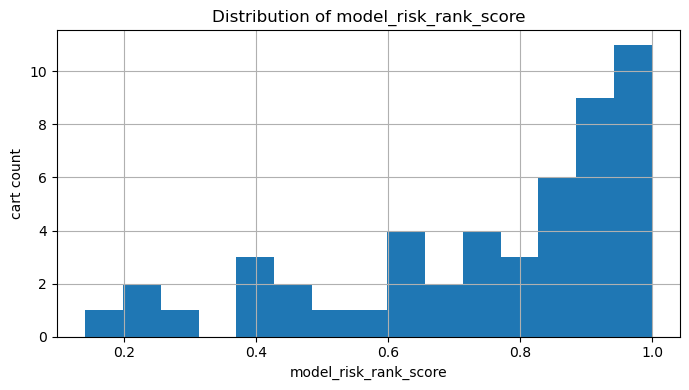

Saved plot: C:\Users\monster\Desktop\returnshield-ai\outputs\05_mock_cart_features\plots\model_risk_rank_score_distribution.png


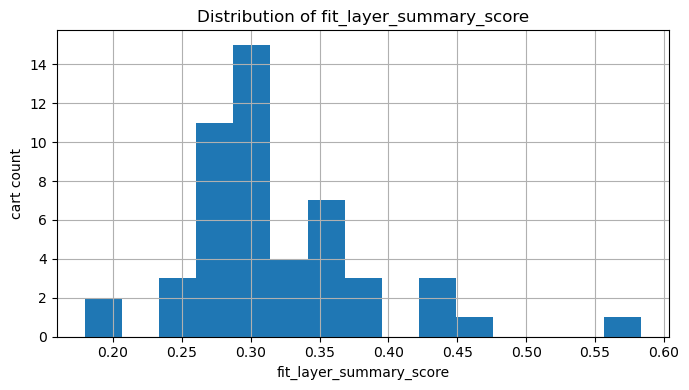

Saved plot: C:\Users\monster\Desktop\returnshield-ai\outputs\05_mock_cart_features\plots\fit_layer_summary_score_distribution.png


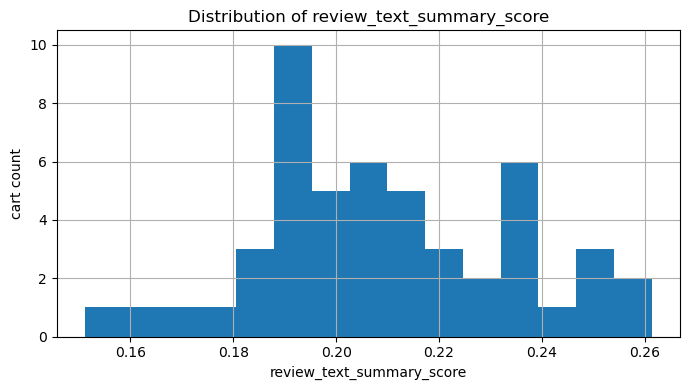

Saved plot: C:\Users\monster\Desktop\returnshield-ai\outputs\05_mock_cart_features\plots\review_text_summary_score_distribution.png


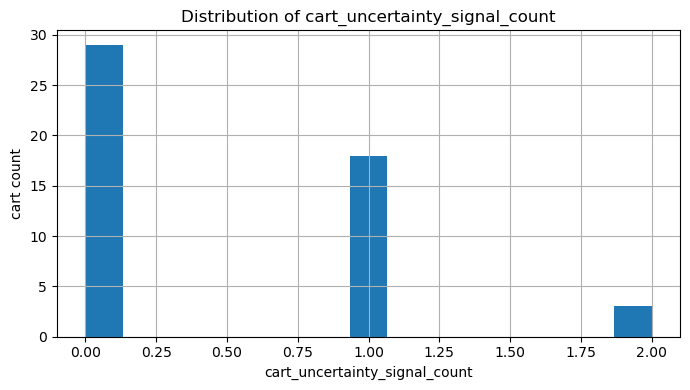

Saved plot: C:\Users\monster\Desktop\returnshield-ai\outputs\05_mock_cart_features\plots\cart_uncertainty_signal_count_distribution.png


In [14]:
# Quick feature distribution views

for col in [
    "model_risk_rank_score",
    "fit_layer_summary_score",
    "review_text_summary_score",
    "cart_uncertainty_signal_count",
]:
    if col not in mock_cart_features_out.columns:
        continue

    plt.figure(figsize=(7, 4))
    mock_cart_features_out[col].hist(bins=15)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("cart count")
    plt.tight_layout()
    plot_path = PLOTS_DIR / f"{col}_distribution.png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved plot:", plot_path)


## Output use

`mock_cart_features.csv` is the final cart-level input table for Notebook 06.

Feature groups:

- transaction layer: `model_risk_rank_score`, `night_purchase`
- fit layer: `fit_layer_summary_score`, `item_fit_issue_score`, `item_length_issue_score`, `item_quality_issue_score`
- review layer: `review_text_summary_score`, separate `review_text_*` scores, upper-tail flags
- cart layer: `two_size_same_product`, `duplicate_variant`, `cart_uncertainty_signal_count`, `cart_size_pressure`
- availability: `fit_signal_available`, `review_signal_available`, `rating_signal_available`

Notebook 05 stops before final risk scoring.
